## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the indices such as NDVI, NDBI, NNDWI and BSI. The script with the computation of the LST can be found [here](https://github.com/EllenB/lstroad/blob/main/notebooks/03_lst_bangalore_band_10.ipynb) and the script for the indices [here](https://github.com/EllenB/lstroad/blob/main/notebooks/04_indices_bangalore.ipynb). 

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [3]:
lst_path = PROCESSED_DIR /'lstband10summer_bang.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_bang.csv


In [4]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [5]:
df_lst_mean_summer.head()

,system:index,ward_name,mean,ward_id
0,0,25 - Vinayaka Layout,39.324657,25
1,1,2 - Aerocity,38.621582,2
2,2,3 - Chowdeshwari ward,38.597490,3
3,3,15 - Ramamurthy Nagara,38.432678,15
4,4,58 - Nagashettyhalli,37.427218,58


In [6]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 35.593766695678646.
The maximum temperature is 42.37974275787706.


### Indices

In [7]:
indices_path = PROCESSED_DIR /'indices_wards_geemap_bang.csv'
df_indices = pd.read_csv(indices_path)

In [8]:
df_indices.head()

,system:index,Corporatio,ward_name,MNDWI,NDBI,BSI,NDVI,ward_id
0,0,West,25 - Vinayaka Layout,-0.337424,-0.022776,0.071129,0.297025,25
1,1,North,2 - Aerocity,-0.337253,-0.029647,0.068905,0.305434,2
2,2,North,3 - Chowdeshwari ward,-0.399920,-0.034285,0.058472,0.368122,3
3,3,East,15 - Ramamurthy Nagara,-0.274119,-0.026672,0.073142,0.249989,15
4,4,North,58 - Nagashettyhalli,-0.323029,-0.038849,0.057884,0.299915,58


In [9]:
merged = pd.merge(df_lst_mean_summer, df_indices, on='ward_name')
merged.head()

,system:index_x,ward_name,mean,ward_id_x,system:index_y,Corporatio,MNDWI,NDBI,BSI,NDVI,ward_id_y
0,0,25 - Vinayaka Layout,39.324657,25,0,West,-0.337424,-0.022776,0.071129,0.297025,25
1,1,2 - Aerocity,38.621582,2,1,North,-0.337253,-0.029647,0.068905,0.305434,2
2,2,3 - Chowdeshwari ward,38.597490,3,2,North,-0.399920,-0.034285,0.058472,0.368122,3
3,3,15 - Ramamurthy Nagara,38.432678,15,3,East,-0.274119,-0.026672,0.073142,0.249989,15
4,4,58 - Nagashettyhalli,37.427218,58,4,North,-0.323029,-0.038849,0.057884,0.299915,58


Only retain the relevant variables and rename:

In [10]:
merged = merged[['ward_name', 'mean', 'ward_id_x', 'Corporatio', 'MNDWI', 'NDBI', 'BSI', 'NDVI']]
merged.head()

,ward_name,mean,ward_id_x,Corporatio,MNDWI,NDBI,BSI,NDVI
0,25 - Vinayaka Layout,39.324657,25,West,-0.337424,-0.022776,0.071129,0.297025
1,2 - Aerocity,38.621582,2,North,-0.337253,-0.029647,0.068905,0.305434
2,3 - Chowdeshwari ward,38.597490,3,North,-0.399920,-0.034285,0.058472,0.368122
3,15 - Ramamurthy Nagara,38.432678,15,East,-0.274119,-0.026672,0.073142,0.249989
4,58 - Nagashettyhalli,37.427218,58,North,-0.323029,-0.038849,0.057884,0.299915


In [11]:
# Rename the columns
merged = merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio': 'Corporation',
    'mean': 'mean_lst'
})
merged.head()

,ward_name,mean_lst,ward_id,Corporation,MNDWI,NDBI,BSI,NDVI
0,25 - Vinayaka Layout,39.324657,25,West,-0.337424,-0.022776,0.071129,0.297025
1,2 - Aerocity,38.621582,2,North,-0.337253,-0.029647,0.068905,0.305434
2,3 - Chowdeshwari ward,38.597490,3,North,-0.399920,-0.034285,0.058472,0.368122
3,15 - Ramamurthy Nagara,38.432678,15,East,-0.274119,-0.026672,0.073142,0.249989
4,58 - Nagashettyhalli,37.427218,58,North,-0.323029,-0.038849,0.057884,0.299915


## Correlations

In [12]:
vars_df = merged[[
    "mean_lst",
    "NDVI",
    "NDBI",
    "BSI",
    "MNDWI"
]].dropna()

In [13]:
corr = vars_df.corr(method="pearson")

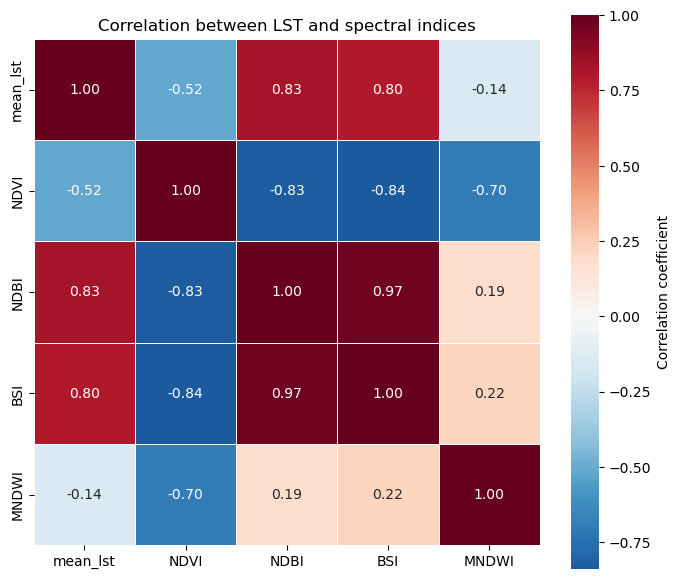

In [14]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()


#### NDVI

In [15]:
# x and y
x = merged[["NDVI"]]
Y = merged["mean_lst"]

In [16]:
fig_path = IMAGES_DIR / 'regression_bangalore_NDVI.png'

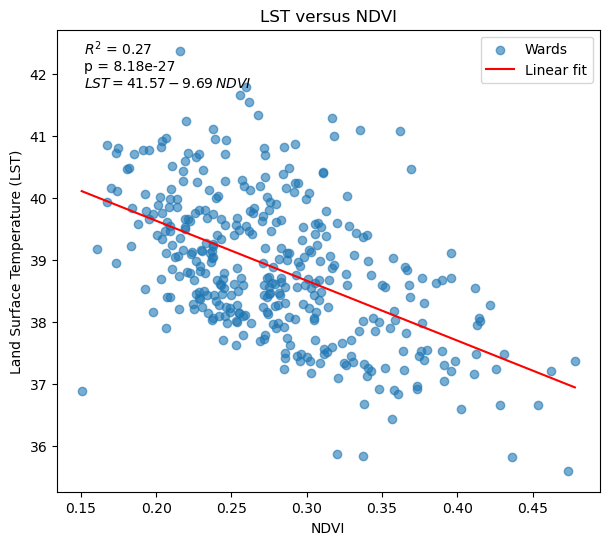

In [17]:
# x and y
x = merged["NDVI"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDVI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDVI")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,NDVI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [18]:
p_value

np.float64(8.179911506004129e-27)

In [19]:
print(slope, intercept, r_value)

-9.68671020227764 41.57003958932748 -0.5188046699937882


In [20]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.5188046699937878), pvalue=np.float64(8.179911506004379e-27))

In [21]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDVI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     135.2
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           8.18e-27
Time:                        22:28:36   Log-Likelihood:                -518.55
No. Observations:                 369   AIC:                             1041.
Df Residuals:                     367   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.5700      0.239    174.102      0.0

In [22]:
pearsonr(merged['NDVI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.5188046699937878), pvalue=np.float64(8.179911506004379e-27))

#### MNDWI

In [23]:
# x and y
x = merged["MNDWI"]
y = merged["mean_lst"]

In [24]:
fig_path = IMAGES_DIR / 'regression_bangalore_MNDWI.png'

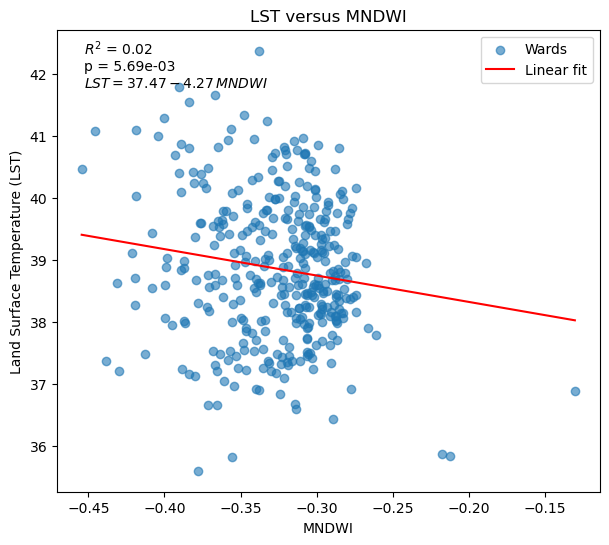

In [25]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("MNDWI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus MNDWI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,MNDWI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [26]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['MNDWI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     7.738
Date:                Wed, 14 Jan 2026   Prob (F-statistic):            0.00569
Time:                        22:28:39   Log-Likelihood:                -572.55
No. Observations:                 369   AIC:                             1149.
Df Residuals:                     367   BIC:                             1157.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.4664      0.504     74.288      0.0

In [27]:
pearsonr(merged['MNDWI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.14369469030365878), pvalue=np.float64(0.005687318738703365))

#### NDBI

In [28]:
# x and y
x = merged["NDBI"]
y = merged["mean_lst"]

In [29]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [30]:
fig_path = IMAGES_DIR / 'regression_bangalore_NDBI.png'

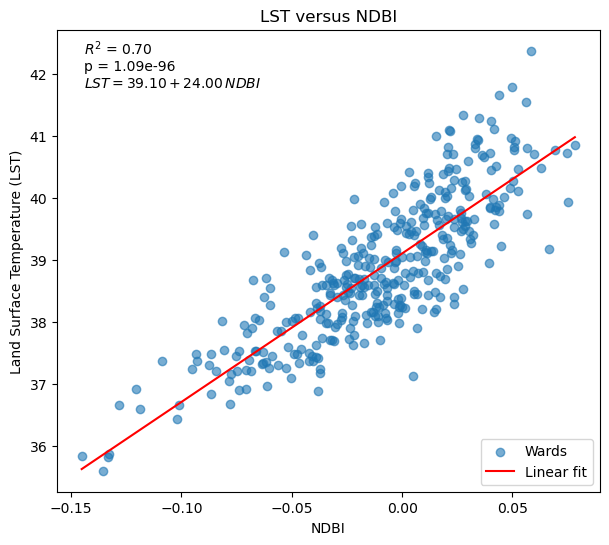

In [31]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("NDBI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus NDBI")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,NDBI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [32]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['NDBI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.695
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     836.7
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.09e-96
Time:                        22:28:43   Log-Likelihood:                -357.25
No. Observations:                 369   AIC:                             718.5
Df Residuals:                     367   BIC:                             726.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.1047      0.034   1139.363      0.0

In [33]:
pearsonr(merged['NDBI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.8337331697061537), pvalue=np.float64(1.0908927248106275e-96))

#### BSI

In [34]:
# x and y
x = merged["BSI"]
y = merged["mean_lst"]

In [35]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [36]:
fig_path = IMAGES_DIR / 'regression_bangalore_BSI.png'

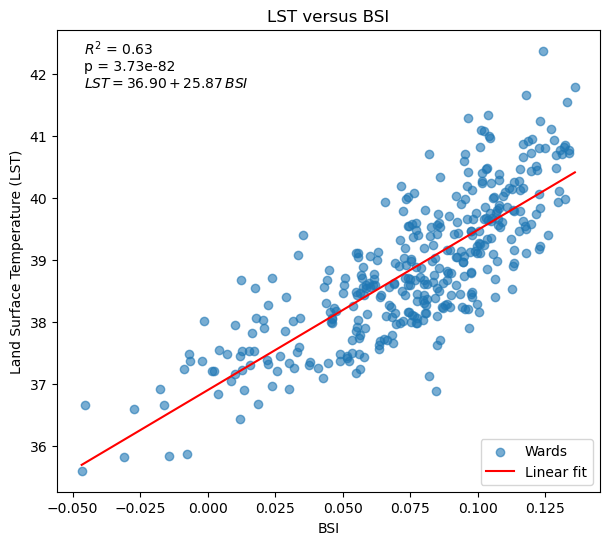

In [37]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("BSI")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus BSI")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,BSI$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [38]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['BSI']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     636.3
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           3.73e-82
Time:                        22:28:49   Log-Likelihood:                -390.85
No. Observations:                 369   AIC:                             785.7
Df Residuals:                     367   BIC:                             793.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.8956      0.086    429.244      0.0

In [39]:
pearsonr(merged['BSI'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.7963708291729776), pvalue=np.float64(3.726689578130631e-82))